<p style = "color : #f54748; font-size : 40px; font-family : 'Comic Sans MS'; text-align : center;"><strong>Linear Regression and Regularization</strong></p>

In [3]:
# necessary imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('fivethirtyeight')

In [17]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df= housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<p style = "font-size : 30px; color : #4e8d7c ; font-family : 'Comic Sans MS';  "><strong>Data Description :-</strong></p>


- MedInc median income in block group
- HouseAge median house age in block group
- AveRooms average number of rooms per household
- AveBedrms average number of bedrooms per household
- Population block group population
- AveOccup average number of household members
- Latitude block group latitude
- Longitude block group longitude

In [20]:
# adding target value to the data

df["MedHouseVal"] = data.target

In [21]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [22]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


<p style = "font-size : 20px; color : #34656d ; font-family : 'Comic Sans MS'; "><strong>It seems there are no missing values in data.</strong></p>

In [24]:
# looking at null values

df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


<p style = "font-size : 20px; color : #34656d ; font-family : 'Comic Sans MS'; "><strong>There are no missing values in the data.</strong></p>

<p style = "color : #f54748; font-size : 35px; font-family : 'Comic Sans MS';"><strong>EDA</strong></p>

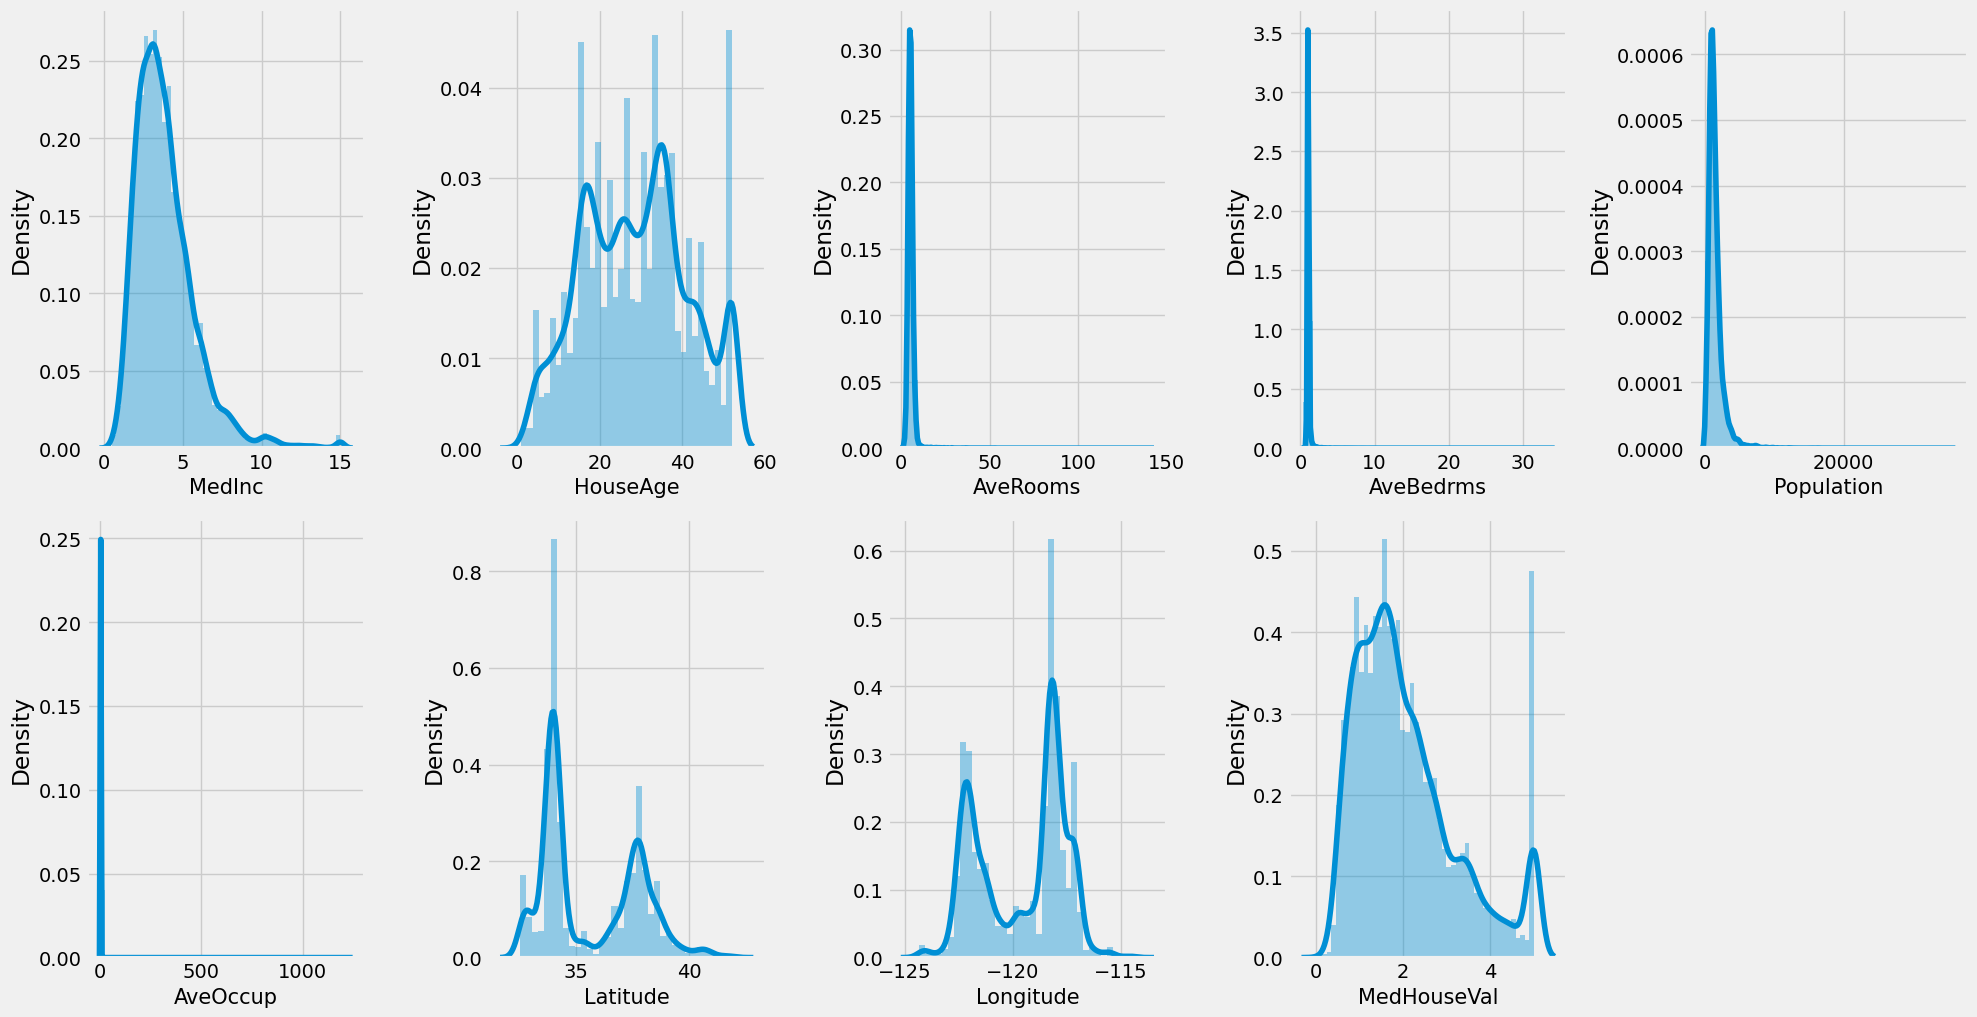

In [25]:
# Let's see how data is distributed for every column

plt.figure(figsize = (20, 15))
plotnumber = 1

for column in df:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column, fontsize = 15)

    plotnumber += 1

plt.tight_layout()
plt.show()

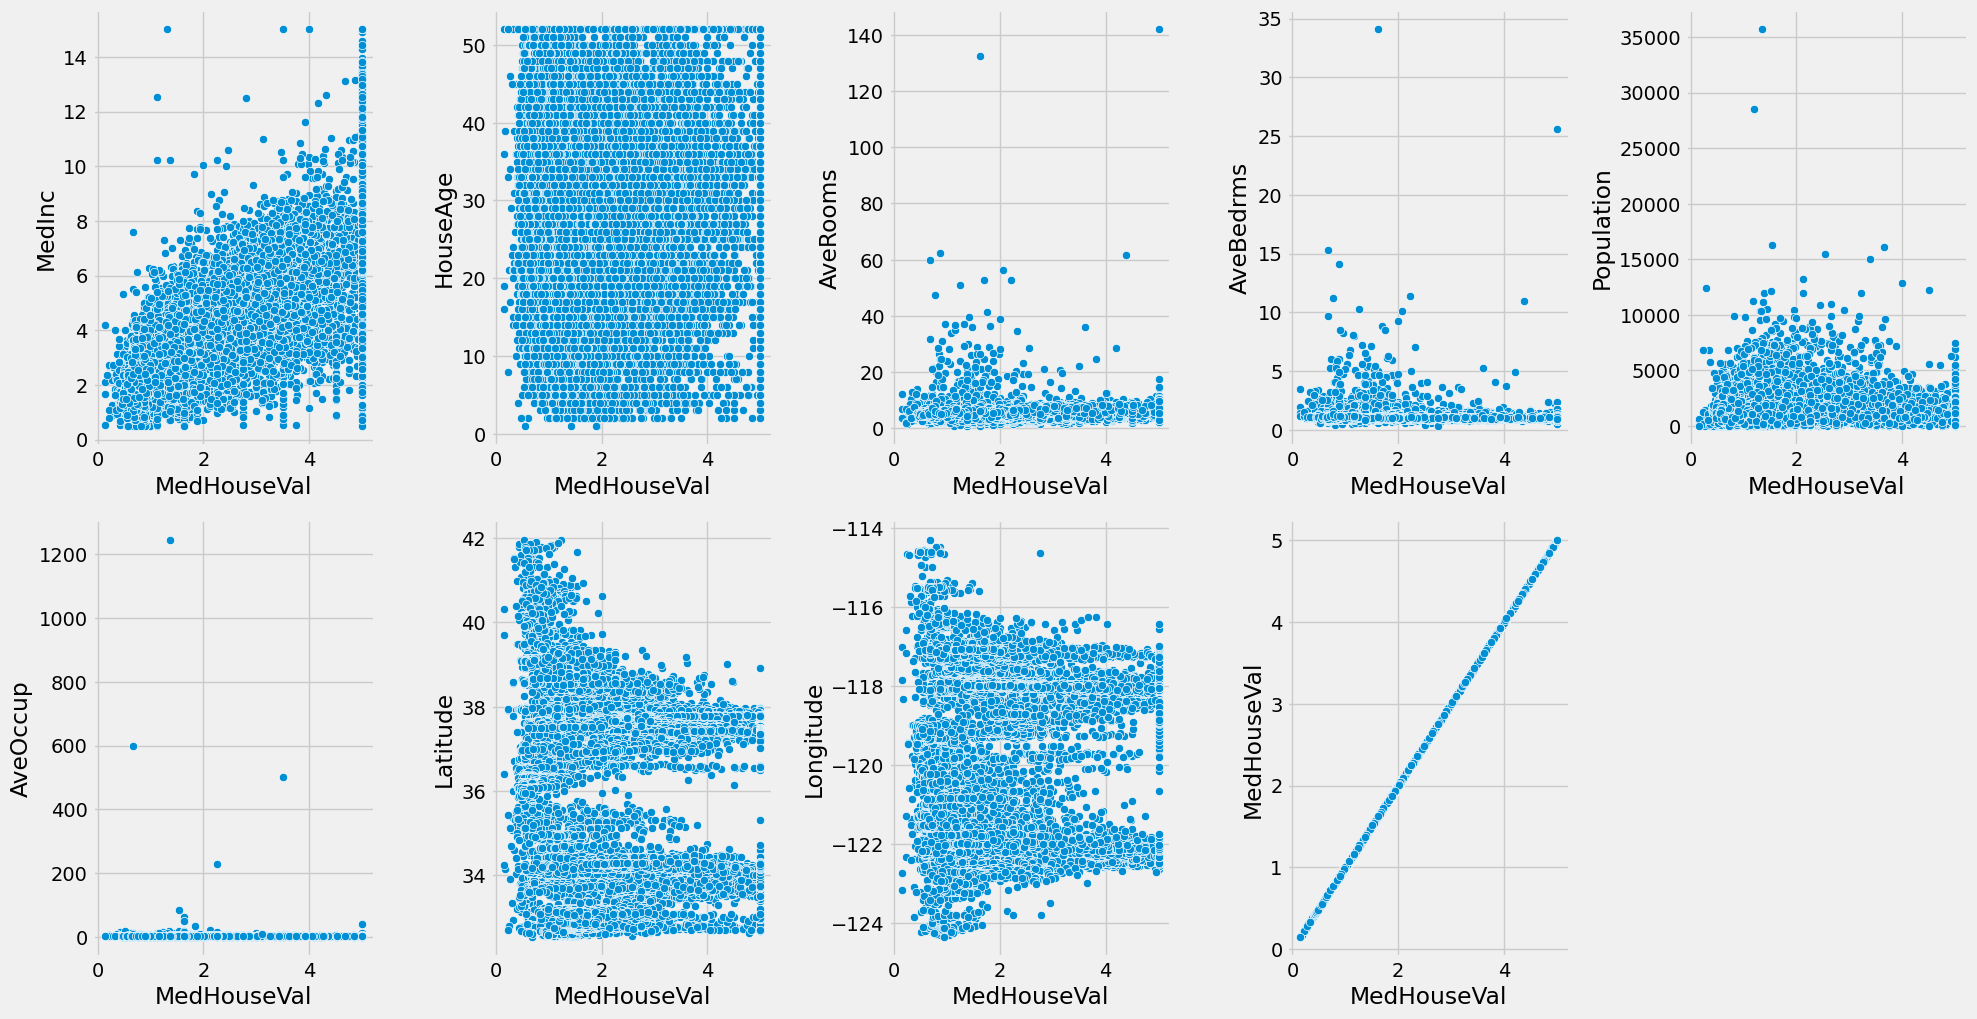

In [26]:
# Plotting `Price` with remaining columns

plt.figure(figsize = (20, 15))
plotnumber = 1

for column in df:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.scatterplot(x = df['MedHouseVal'], y = df[column])

    plotnumber += 1

plt.tight_layout()
plt.show()

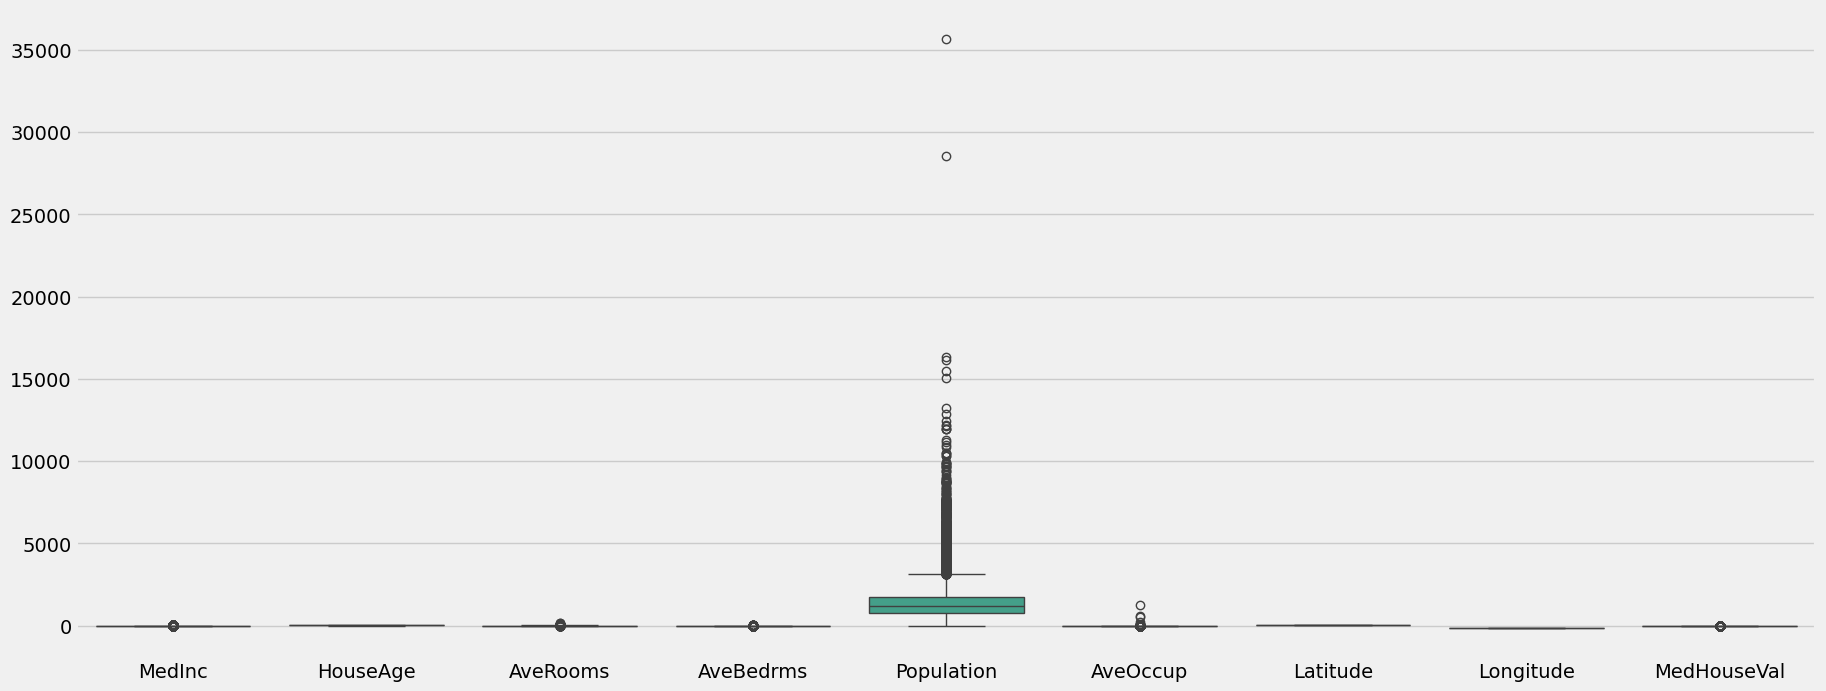

In [27]:
# looking for outliers using box plot

plt.figure(figsize = (20, 8))
sns.boxplot(data = df, width = 0.8)
plt.show()

<p style = "font-size : 20px; color : #34656d ; font-family : 'Comic Sans MS'; "><strong>There are some outliers in data, so StandardScaler can help in scaling data.</strong></p>

In [28]:
# creating features and label variable

X = df.drop(columns = 'MedHouseVal', axis = 1)
y = df['MedHouseVal']

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

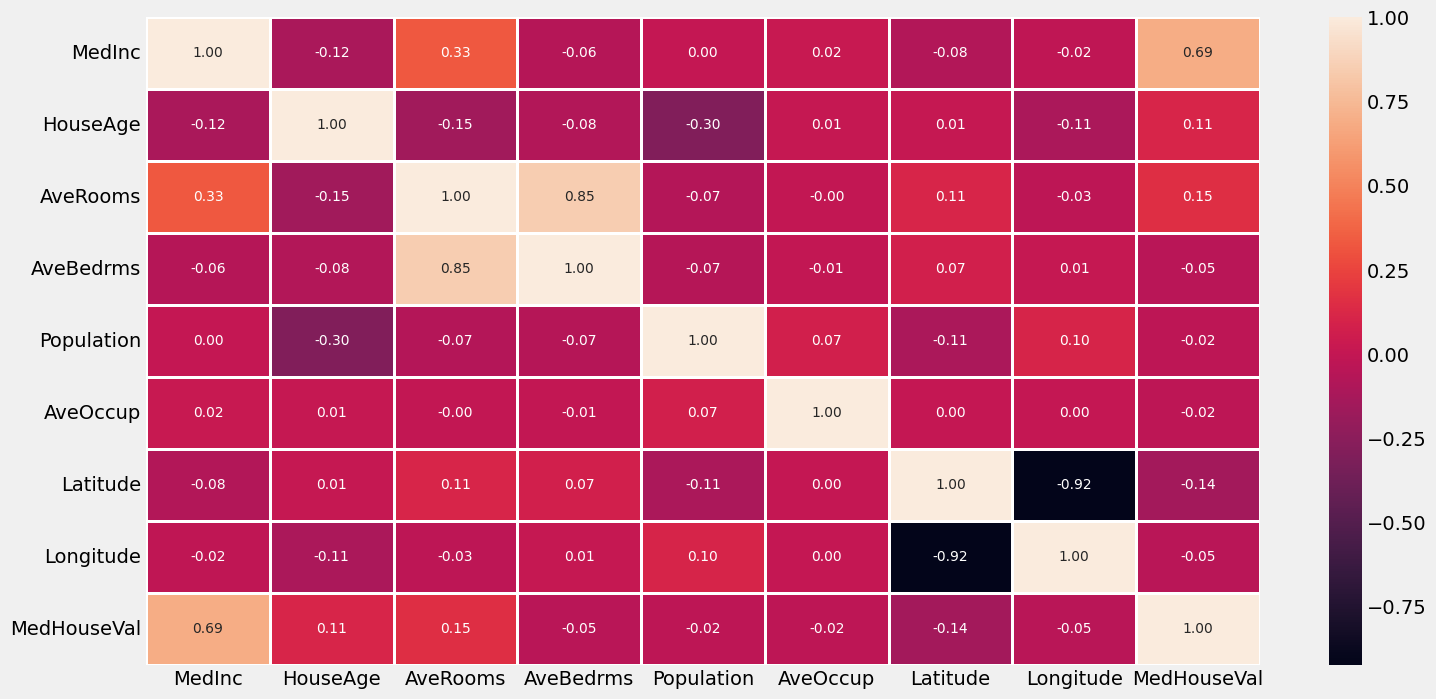

In [31]:
# Heatmap

fig, ax = plt.subplots(figsize = (16, 8))
sns.heatmap(df.corr(), annot = True, fmt = '1.2f', annot_kws = {'size' : 10}, linewidth = 1)
plt.show()

In [32]:
# splitting data into training asnd test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.30, random_state = 0)

In [33]:
# fitting training data to model

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [34]:
# prediction of model

y_pred = lr.predict(X_test)

In [35]:
# training accuracy of model

lr.score(X_train, y_train)

0.6112941337977225

In [36]:
# test accuracy of model

lr.score(X_test, y_test)

0.5926087785518777

<p style = "color : #f54748; font-size : 35px; font-family : 'Comic Sans MS';"><strong>Lasso Regression</strong></p>

In [39]:
from sklearn.linear_model import Lasso, LassoCV

lasso_cv = LassoCV(alphas = None, cv = 10, max_iter = 100000)
lasso_cv.fit(X_train, y_train)

LassoCV(cv=10, max_iter=100000)

In [40]:
# best alpha parameter

alpha = lasso_cv.alpha_
alpha

np.float64(0.003213927112546175)

In [41]:
lasso = Lasso(alpha = lasso_cv.alpha_)
lasso.fit(X_train, y_train)

Lasso(alpha=np.float64(0.003213927112546175))

In [42]:
lasso.score(X_train, y_train)

0.6108607055658635

In [43]:
lasso.score(X_test, y_test)

0.5924328593031551

<p style = "color : #f54748; font-size : 35px; font-family : 'Comic Sans MS';"><strong>Ridge Regression</strong></p>

In [46]:
from sklearn.linear_model import Ridge, RidgeCV

alphas = np.random.uniform(0, 10, 50)
ridge_cv = RidgeCV(alphas = alphas, cv = 10,)
ridge_cv.fit(X_train, y_train)

RidgeCV(alphas=array([6.09150772, 0.81787692, 5.84074487, 6.83985278, 9.09666267,
       9.95508879, 4.89560787, 2.54582126, 7.79690407, 3.26326062,
       3.33988498, 9.75022714, 5.88105138, 9.68126896, 6.91381345,
       9.06150592, 3.9592238 , 6.07143605, 5.83310256, 6.99623777,
       8.22123326, 8.77410971, 5.95432805, 6.45134933, 5.54358415,
       9.37997403, 9.45205907, 6.73264564, 6.82360049, 9.30938075,
       2.93761119, 6.46033309, 0.99524378, 2.72616804, 8.55913426,
       0.79199391, 2.57114782, 3.92676245, 5.83512101, 7.05940682,
       4.28494333, 6.78205462, 5.9087868 , 5.82340812, 9.77837835,
       7.26673693, 2.17850745, 3.17796122, 7.61035416, 7.83230383]),
        cv=10)

In [47]:
# best alpha parameter

alpha = ridge_cv.alpha_
alpha

np.float64(9.955088786248853)

In [48]:
ridge = Ridge(alpha = ridge_cv.alpha_)
ridge.fit(X_train, y_train)

Ridge(alpha=np.float64(9.955088786248853))

In [49]:
ridge.score(X_train, y_train)

0.6112858579891522

In [50]:
ridge.score(X_test, y_test)

0.5925416720444281